In [1]:
# enable all interactive output to be 'printed'
# and disable scrolling so long output can be displayed w/o scroll bars

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
# methods for displaying and maintaining an image in jupyter frontend
from IPython.display import Image, display
# methods for displaying and maintaining an image in jupyter frontend
from IPython.display import Image, display

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Import libraries for retrieving image data
import os
import scipy
import numpy as np
from pathlib import Path

from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [5]:
# Retrieve image data
extract_path = os.getcwd() + '\elephant_dataset'

train_dir = Path(extract_path) / "train"
test_dir = Path(extract_path) / "test"

# Print the contents
print("Training data folders:", os.listdir(train_dir))
print("Testing data folders:", os.listdir(test_dir))

# These directories should have two subfolders: 'asian' and 'african'

Training data folders: ['African', 'Asian']
Testing data folders: ['African', 'Asian']


In [6]:
# Step 3: Resize and Normalize Images

image_size = (128, 128)  # previous resizing was 150x150 pixels
batch_size = 32

In [7]:
# Step 4: Set Up Image Data Generators

# Keras' ImageDataGenerator is used for:
# 1. Rescaling pixel values
# 2. Real-time data augmentation (which helps prevent overfitting)
# 3. Loading images in batches for training and validation

# Create an ImageDataGenerator instance for the training data, including augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,         # Normalize the images by dividing pixel values by 255 (to scale between 0 and 1)
    rotation_range=40,     # Randomly rotate images by 0 to 40 degrees
    width_shift_range=0.2, # Shift images horizontally by 20% of the total width
    height_shift_range=0.2,# Shift images vertically by 20% of the total height
    shear_range=0.2,       # Apply shearing transformation to images
    zoom_range=0.2,        # Randomly zoom the images
    horizontal_flip=True,  # Flip images horizontally for data augmentation
    fill_mode='nearest'    # Fill missing pixels after transformation with nearest pixel values
)

# Create a validation data generator (we don't want augmentation here, only rescaling)
test_datagen = ImageDataGenerator(rescale=1./255)

print("ImageDataGenerator created")

ImageDataGenerator created


In [8]:
# Step 5: Load Images from Directories

# Using flow_from_directory to load and preprocess images from the directory
# This function will automatically categorize images based on the folder names ('asian', 'african').

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,     # Path to the train directory
    target_size=image_size,  # Resize images to 150x150 pixels
    batch_size=batch_size,   # Set the batch size for the data
    class_mode='binary'      # Since this is a binary classification task (Asian vs African elephants)
)

test_generator = test_datagen.flow_from_directory(
    directory=test_dir,       # Path to the validation directory
    target_size=image_size,  # Resize images to 150x150 pixels
    batch_size=batch_size,   # Set the batch size for validation data
    class_mode='binary'      # Binary classification (either 'asian' or 'african')
)

(print(type(test_generator)))

Found 1010 images belonging to 2 classes.
Found 100 images belonging to 2 classes.
<class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>


In [9]:
# Import libraries for model training and testing

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [10]:
# 6. Define the Model Architecture
model = models.Sequential([

    # Step 1: Add the first Convolutional layer
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(128, 128, 3)),

    # Step 2: Add another Conv2D layer
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),

    # Step 3: Add MaxPooling after second Conv2D
    layers.MaxPooling2D(),

    # Step 4: Add another Conv2D layer
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),

    # Step 5: Add MaxPooling after third Conv2D
    layers.MaxPooling2D(),

    # Step 6: Add Conv2D with more filters
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),

    # Step 7: Add MaxPooling after fourth Conv2D
    layers.MaxPooling2D(),

    # Step 8: Add Dropout to prevent overfitting
    layers.Dropout(0.2),

    # Step 9: Flatten the output
    layers.Flatten(),

    # Step 10: Add Dense layer with 128 units and ReLU activation
    layers.Dense(128, activation='relu'),

    # Step 11: Add the final output layer with sigmoid activation for binary classification
    layers.Dense(1, activation='sigmoid')
])

In [11]:
# Summarize the model architecture

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 128, 128, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 128, 128, 32)        │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 64, 64, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 32, 32, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 32, 32, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       2,097,280 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,135,297 (8.15 MB)

 Trainable params: 2,135,297 (8.15 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# 7. Compile the Model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
# 7. Define EarlyStopping and ModelCheckpoint callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# checkpoint = ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True)
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True)

In [14]:
# 9. Train the Model
history = model.fit(
    train_generator,  # Assuming train_generator is already defined
    epochs=10,        # You can modify the number of epochs based on your data
    validation_data=test_generator,  # Assuming val_generator is already defined
    callbacks=[early_stopping, checkpoint]
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 163s 4s/step - accuracy: 0.4922 - loss: 0.6954 - val_accuracy: 0.5000 - val_loss: 0.6982
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 139s 3s/step - accuracy: 0.5451 - loss: 0.6867 - val_accuracy: 0.6700 - val_loss: 0.6488
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 140s 4s/step - accuracy: 0.5665 - loss: 0.6792 - val_accuracy: 0.7400 - val_loss: 0.6014
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 126s 3s/step - accuracy: 0.6223 - loss: 0.6483 - val_accuracy: 0.7600 - val_loss: 0.5758
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.6163 - loss: 0.6483 - val_accuracy: 0.7700 - val_loss: 0.5483
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 121s 3s/step - accuracy: 0.6545 - loss: 0.6386 - val_accuracy: 0.7800 - val_loss: 0.5503
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 137s 4s/step - accuracy: 0.6250 - loss: 0.6460 - val_accuracy: 0.7800 - val_loss: 0.5249
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 144s 4s/step - accuracy: 0.6056 - loss: 0.6548 - val_accuracy: 0.7600 - v

In [15]:
# 10. Evaluate the Model
# After training, evaluate the model on the test data
test_loss, test_accuracy = model.evaluate(test_generator)  # Assuming test_generator is already defined
print(f'Test Loss: {test_loss}, Test Accuracy: {test_accuracy}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 19s 4s/step - accuracy: 0.7573 - loss: 0.4750
Test Loss: 0.49062052369117737, Test Accuracy: 0.75


In [16]:
# libraries for plotting

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

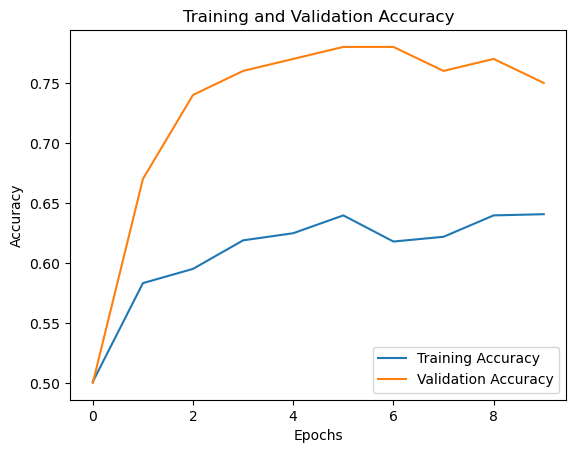

In [17]:
# 11. Plot the training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show();

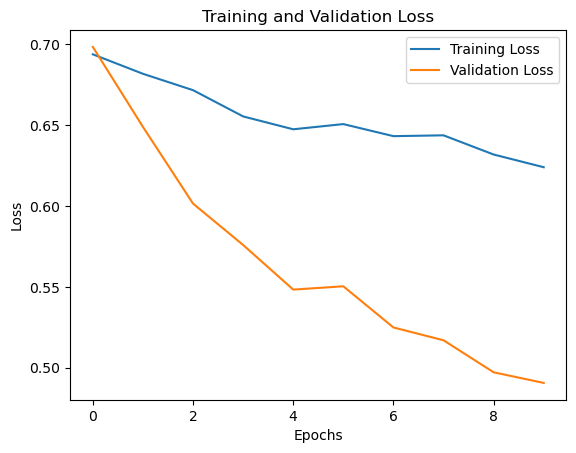

In [18]:
# 11. Plot the training and validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show();